VALENTINA ACEVEDO MESA - 

LUIS EDUARDO GRAJALES HERNANDEZ - 

JUAN JOSÉ GARCÉS ROJAS - 1007409305

# Consulta: índices del EEG adicionales a la densidad espectral de potencia para clasificación en BCI

En este proyecto se busca analizar señales EEG asociadas a condiciones de reposo, imaginación de movimiento de mano izquierda e imaginación de movimiento de mano derecha. En el dataset EEG Motor Movement/Imagery, los eventos `T0`, `T1` y `T2` permiten identificar las condiciones experimentales. Para los runs 3, 4, 7, 8, 11 y 12, `T0` corresponde a reposo, `T1` corresponde a movimiento o imaginación de movimiento de la mano izquierda y `T2` corresponde a movimiento o imaginación de movimiento de la mano derecha [1].

Aunque la densidad espectral de potencia permite estudiar cómo se distribuye la energía de la señal EEG en diferentes bandas de frecuencia, en sistemas BCI basados en imaginación motora no siempre es suficiente usar únicamente este tipo de característica. Las señales EEG son no estacionarias, variables entre sujetos y pueden tener información relevante en el dominio temporal, espacial, tiempo-frecuencia y no lineal. Por esta razón, en la literatura se han propuesto diferentes índices adicionales para mejorar la representación de la señal y apoyar la clasificación de estados en BCI [2].

A continuación, se presentan índices adicionales a la densidad espectral de potencia que pueden implementarse en Python y que pueden aportar información útil para clasificar estados de reposo, imaginación de movimiento de mano izquierda e imaginación de movimiento de mano derecha.

---

## 1. Patrones Espaciales Comunes (Common Spatial Patterns, CSP)

Los Patrones Espaciales Comunes, conocidos como CSP, son una técnica de extracción de características espaciales ampliamente utilizada en BCI con EEG, especialmente en tareas de imaginación motora. El objetivo de CSP es encontrar combinaciones espaciales de los canales EEG que maximicen la varianza de una clase y minimicen la varianza de otra. De esta manera, los canales originales se transforman en nuevos componentes que resaltan mejor las diferencias entre condiciones [3].

Este índice es útil en imaginación motora porque las tareas de mano derecha y mano izquierda generan cambios en zonas sensorimotoras del cerebro. Por ejemplo, los canales `C3`, `Cz` y `C4` suelen ser de interés porque están relacionados con la actividad motora. En trabajos clásicos de BCI se ha demostrado que los filtros espaciales en EEG multicanal permiten extraer información discriminativa entre ensayos de imaginación de movimiento de mano izquierda y derecha [3].

Además, la librería MNE-Python incluye ejemplos de decodificación de imaginación motora usando CSP, donde las señales EEG son filtradas, transformadas con CSP y luego usadas como entrada para un clasificador [4].

**Aplicación en el proyecto:**

En este proyecto, CSP puede aplicarse sobre las épocas de EEG filtradas entre 8 y 30 Hz, rango que incluye principalmente los ritmos mu y beta. Las características obtenidas pueden usarse para comparar reposo, imaginación de mano izquierda e imaginación de mano derecha, o directamente para entrenar clasificadores como SVM, XGBoost o redes neuronales.

---

## 2. Parámetros de Hjorth

Los parámetros de Hjorth son características temporales que describen propiedades de la forma y variabilidad de una señal EEG. Estos parámetros fueron propuestos para el análisis de señales EEG en el dominio del tiempo y se componen principalmente de actividad, movilidad y complejidad [5].

### Actividad

La actividad mide la varianza de la señal. Se relaciona con la amplitud o energía general de la señal en el tiempo [5].

$$
Actividad = var(x(t))
$$

### Movilidad

La movilidad mide qué tan rápido cambia la señal en el tiempo. Se calcula a partir de la relación entre la varianza de la derivada de la señal y la varianza de la señal original [5].

$$
Movilidad = \sqrt{\frac{var(\frac{dx(t)}{dt})}{var(x(t))}}
$$

### Complejidad

La complejidad mide qué tan variable o irregular es la forma de la señal. Se calcula comparando la movilidad de la derivada con la movilidad de la señal original [5].

$$
Complejidad = \frac{Movilidad(\frac{dx(t)}{dt})}{Movilidad(x(t))}
$$

Estos parámetros son útiles porque permiten describir la señal EEG directamente en el dominio temporal, sin depender únicamente del análisis frecuencial. Además, tienen bajo costo computacional y pueden calcularse fácilmente para cada canal y cada época. En estudios de procesamiento EEG para imaginación motora se ha señalado que el análisis de estas señales requiere considerar tanto características temporales como frecuenciales debido a su comportamiento no estacionario [6].

**Aplicación en el proyecto:**

Para cada segmento EEG se pueden calcular los parámetros de Hjorth en los canales `C3`, `Cz` y `C4`. Por ejemplo:

- Actividad en C3.
- Movilidad en C3.
- Complejidad en C3.
- Actividad en C4.
- Movilidad en C4.
- Complejidad en C4.

Estos valores pueden almacenarse en un dataframe junto con el sujeto, el run y la condición evaluada.

---

## 3. Entropía de la señal EEG

La entropía es una medida que permite cuantificar el grado de irregularidad, desorden o complejidad de una señal. En EEG, puede ayudar a identificar diferencias entre condiciones que no son evidentes únicamente mediante la densidad espectral de potencia.

En paradigmas BCI de imaginación motora se han usado diferentes tipos de entropía, como entropía de Shannon, entropía muestral, entropía aproximada, entropía difusa y entropía de permutación. Una revisión enfocada en entropía aplicada a MI-BCI reporta que estas medidas son usadas como características para describir la complejidad de la señal EEG y apoyar tareas de clasificación [7].

Una señal más regular o más predecible tiende a presentar menor entropía, mientras que una señal más irregular tiende a presentar mayor entropía. Esto puede ser útil para comparar si las condiciones de reposo, mano izquierda imaginada y mano derecha imaginada presentan diferencias en la complejidad de la actividad cerebral.

**Aplicación en el proyecto:**

En este proyecto se puede implementar, por ejemplo, la entropía de permutación o la entropía muestral para cada época y cada canal. Estas características pueden complementar la información obtenida mediante la densidad espectral de potencia y los parámetros temporales.

---

## 4. Características tiempo-frecuencia mediante Wavelet

La transformada wavelet permite analizar cómo cambia el contenido frecuencial de una señal a lo largo del tiempo. Esto es importante en EEG porque las señales cerebrales no son completamente estacionarias. A diferencia de la densidad espectral de potencia tradicional, que resume la información frecuencial de un segmento completo, la transformada wavelet permite observar variaciones temporales dentro de la señal [8].

En clasificación de imaginación motora se han usado características basadas en wavelet, como energía por subbanda, entropía wavelet y características obtenidas mediante wavelet packet. Estos métodos permiten representar la señal EEG en el dominio tiempo-frecuencia y pueden aportar información complementaria para la clasificación [8], [9].

**Aplicación en el proyecto:**

En este proyecto se puede aplicar una transformada wavelet discreta a cada época EEG y calcular características como:

- Energía wavelet en C3.
- Entropía wavelet en C3.
- Energía wavelet en C4.
- Entropía wavelet en C4.
- Energía relativa por subbanda.

Estas características pueden compararse entre reposo, imaginación de mano izquierda e imaginación de mano derecha.

---

## Índices seleccionados para implementar

Para este proyecto se propone implementar los siguientes índices adicionales a la densidad espectral de potencia:

| Índice | Tipo de característica | Utilidad en BCI |
|---|---|---|
| CSP | Espacial | Resalta diferencias entre condiciones usando varios canales EEG |
| Parámetros de Hjorth | Temporal | Describe amplitud, variabilidad y complejidad de la señal |
| Entropía | No lineal | Mide irregularidad o complejidad de la señal EEG |
| Wavelet | Tiempo-frecuencia | Captura cambios de frecuencia a lo largo del tiempo |

Aunque todos los índices anteriores pueden aportar información útil, los tres más recomendados para iniciar el análisis son CSP, parámetros de Hjorth y entropía. Estos índices son relativamente directos de implementar en Python, complementan el análisis basado en potencia espectral y pueden generar características útiles para los modelos de clasificación.

---

## Conclusión

Con base en la revisión realizada, se concluye que para mejorar la clasificación de estados en BCI no es suficiente analizar únicamente la densidad espectral de potencia. En tareas de imaginación motora, las diferencias entre condiciones pueden observarse también en la distribución espacial de la actividad EEG, en la forma temporal de la señal, en su complejidad no lineal y en su comportamiento tiempo-frecuencia [2], [3], [7].

Por esta razón, se seleccionan como índices adicionales los Patrones Espaciales Comunes, los parámetros de Hjorth, la entropía y las características wavelet. Estos índices pueden calcularse sobre las épocas correspondientes a reposo, imaginación de mano izquierda e imaginación de mano derecha, y posteriormente utilizarse como entradas para modelos de clasificación.

---

## Referencias

[1] PhysioNet. *EEG Motor Movement/Imagery Dataset*. Disponible en:  
https://archive.physionet.org/pn4/eegmmidb/

[2] Degirmenci, M. et al. *Statistically significant features improve binary and multiple Motor Imagery task predictions from EEGs*. Frontiers in Human Neuroscience. Disponible en:  
https://www.frontiersin.org/journals/human-neuroscience/articles/10.3389/fnhum.2023.1223307/full

[3] Ramoser, H., Müller-Gerking, J., & Pfurtscheller, G. (2000). *Optimal spatial filtering of single trial EEG during imagined hand movement*. IEEE Transactions on Rehabilitation Engineering. Disponible en:  
https://pubmed.ncbi.nlm.nih.gov/11204034/

[4] MNE-Python. *Motor imagery decoding from EEG data using the Common Spatial Pattern (CSP)*. Disponible en:  
https://mne.tools/stable/auto_examples/decoding/decoding_csp_eeg.html

[5] Hjorth, B. (1970). *EEG analysis based on time domain properties*. Electroencephalography and Clinical Neurophysiology.

[6] Oh, S. H., Lee, Y. R., & Kim, H. N. *A Novel EEG Feature Extraction Method using Hjorth Parameter*. Disponible en:  
https://cspl.pusan.ac.kr/sites/cspl/download/internation_c/ICAEE2014_02_OSH.pdf

[7] *The Application of Entropy in Motor Imagery Paradigms of Brain–Computer Interfaces*. Disponible en:  
https://pmc.ncbi.nlm.nih.gov/articles/PMC11853529/

[8] *Motor imagery classification method based on relative wavelet packet energy and cloud model*. Disponible en:  
https://pmc.ncbi.nlm.nih.gov/articles/PMC9936148/

[9] *Feature Extraction of Motor Imagery EEG via Discrete Wavelet Transform*. Disponible en:  
https://www.mdpi.com/2079-9292/12/10/2207

In [1]:
# ============================================================
# 1. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ============================================================

!pip -q install mne tqdm

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from tqdm import tqdm

In [2]:
# ============================================================
# 2. RUTAS DEL PROYECTO
# ============================================================

ZIP_PATH = Path("eeg-motor-movementimagery-dataset-1.0.0.zip")
DATA_DIR = Path("data_eeg")
RESULTS_DIR = Path("resultados")

DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Ruta del ZIP:", ZIP_PATH.resolve())
print("Carpeta de datos:", DATA_DIR.resolve())
print("Carpeta de resultados:", RESULTS_DIR.resolve())

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        "No se encontró el archivo ZIP. "
        "Verifica que 'eeg-motor-movementimagery-dataset-1.0.0.zip' esté en la misma carpeta del notebook."
    )
else:
    print("ZIP encontrado correctamente.")

Ruta del ZIP: C:\Users\ASUS\Downloads\eeg-motor-movementimagery-dataset-1.0.0.zip
Carpeta de datos: C:\Users\ASUS\Downloads\data_eeg
Carpeta de resultados: C:\Users\ASUS\Downloads\resultados
ZIP encontrado correctamente.


In [3]:
# ============================================================
# 3. EXTRAER EL ZIP SOLO SI AÚN NO HAY ARCHIVOS EDF
# ============================================================

edf_existentes = list(DATA_DIR.rglob("*.edf"))

if len(edf_existentes) == 0:
    print("Extrayendo archivos del ZIP...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    print("Extracción finalizada.")
else:
    print("Ya hay archivos EDF extraídos. No se vuelve a extraer.")

Extrayendo archivos del ZIP...
Extracción finalizada.


In [4]:
# ============================================================
# 4. BUSCAR TODOS LOS ARCHIVOS EDF
# ============================================================

edf_files = sorted(DATA_DIR.rglob("*.edf"))

print("Cantidad total de archivos EDF encontrados:", len(edf_files))

for archivo in edf_files[:10]:
    print(archivo)

Cantidad total de archivos EDF encontrados: 1526
data_eeg\files\S001\S001R01.edf
data_eeg\files\S001\S001R02.edf
data_eeg\files\S001\S001R03.edf
data_eeg\files\S001\S001R04.edf
data_eeg\files\S001\S001R05.edf
data_eeg\files\S001\S001R06.edf
data_eeg\files\S001\S001R07.edf
data_eeg\files\S001\S001R08.edf
data_eeg\files\S001\S001R09.edf
data_eeg\files\S001\S001R10.edf


In [5]:
# ============================================================
# 5. SELECCIÓN DE RUNS DE INTERÉS
# ============================================================

# Para imaginación motora mano izquierda y mano derecha:
runs_imaginacion = ["R04", "R08", "R12"]

# Para movimiento real mano izquierda y mano derecha, si también lo necesitan:
runs_movimiento_real = ["R03", "R07", "R11"]

# Por ahora empecemos con imaginación motora
runs_interes = runs_imaginacion

edf_interes = [
    archivo for archivo in edf_files
    if any(run in archivo.name for run in runs_interes)
]

print("Cantidad de archivos de interés:", len(edf_interes))

for archivo in edf_interes[:20]:
    print(archivo.name)

Cantidad de archivos de interés: 327
S001R04.edf
S001R08.edf
S001R12.edf
S002R04.edf
S002R08.edf
S002R12.edf
S003R04.edf
S003R08.edf
S003R12.edf
S004R04.edf
S004R08.edf
S004R12.edf
S005R04.edf
S005R08.edf
S005R12.edf
S006R04.edf
S006R08.edf
S006R12.edf
S007R04.edf
S007R08.edf


In [6]:
# ============================================================
# 6. SELECCIONAR UN ARCHIVO DE PRUEBA
# ============================================================

archivo_prueba = None

for archivo in edf_interes:
    if "S001R04" in archivo.name:
        archivo_prueba = archivo
        break

print("Archivo seleccionado:")
print(archivo_prueba)

if archivo_prueba is None:
    raise FileNotFoundError("No se encontró S001R04.edf dentro de los archivos extraídos.")

Archivo seleccionado:
data_eeg\files\S001\S001R04.edf


In [7]:
# ============================================================
# 7. FUNCIÓN PARA LIMPIAR NOMBRES DE CANALES
# ============================================================

def limpiar_nombres_canales(raw):
    """
    Limpia los nombres de canales del dataset.
    Ejemplo:
    'C3..' -> 'C3'
    'Cz..' -> 'Cz'
    'C4..' -> 'C4'
    """
    nuevos_nombres = {}

    for canal in raw.ch_names:
        canal_limpio = canal.replace(".", "").replace(" ", "")
        nuevos_nombres[canal] = canal_limpio

    raw.rename_channels(nuevos_nombres)
    return raw

In [8]:
# ============================================================
# 8. LEER EL ARCHIVO EDF
# ============================================================

raw = mne.io.read_raw_edf(
    archivo_prueba,
    preload=True,
    verbose=False
)

raw = limpiar_nombres_canales(raw)

print(raw)
print("Frecuencia de muestreo:", raw.info["sfreq"], "Hz")
print("Número de canales:", len(raw.ch_names))
print("Duración:", raw.times[-1], "segundos")

print("\nPrimeros canales:")
print(raw.ch_names[:20])

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Frecuencia de muestreo: 160.0 Hz
Número de canales: 64
Duración: 124.99375 segundos

Primeros canales:
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4']


In [9]:
# ============================================================
# 9. REVISAR ANOTACIONES DEL ARCHIVO
# ============================================================

print(raw.annotations)

for onset, duration, description in zip(
    raw.annotations.onset,
    raw.annotations.duration,
    raw.annotations.description
):
    print(f"Inicio: {onset:.2f} s | Duración: {duration:.2f} s | Evento: {description}")

<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>
Inicio: 0.00 s | Duración: 4.20 s | Evento: T0
Inicio: 4.20 s | Duración: 4.10 s | Evento: T2
Inicio: 8.30 s | Duración: 4.20 s | Evento: T0
Inicio: 12.50 s | Duración: 4.10 s | Evento: T1
Inicio: 16.60 s | Duración: 4.20 s | Evento: T0
Inicio: 20.80 s | Duración: 4.10 s | Evento: T1
Inicio: 24.90 s | Duración: 4.20 s | Evento: T0
Inicio: 29.10 s | Duración: 4.10 s | Evento: T2
Inicio: 33.20 s | Duración: 4.20 s | Evento: T0
Inicio: 37.40 s | Duración: 4.10 s | Evento: T2
Inicio: 41.50 s | Duración: 4.20 s | Evento: T0
Inicio: 45.70 s | Duración: 4.10 s | Evento: T1
Inicio: 49.80 s | Duración: 4.20 s | Evento: T0
Inicio: 54.00 s | Duración: 4.10 s | Evento: T2
Inicio: 58.10 s | Duración: 4.20 s | Evento: T0
Inicio: 62.30 s | Duración: 4.10 s | Evento: T1
Inicio: 66.40 s | Duración: 4.20 s | Evento: T0
Inicio: 70.60 s | Duración: 4.10 s | Evento: T2
Inicio: 74.70 s | Duración: 4.20 s | Evento: T0
Inicio: 78.90 s | Duración: 4.10 s | E

In [10]:
# ============================================================
# 10. SELECCIONAR CANALES DE INTERÉS
# ============================================================

canales_interes = ["C3", "Cz", "C4"]

canales_disponibles = [
    canal for canal in canales_interes
    if canal in raw.ch_names
]

print("Canales disponibles:", canales_disponibles)

raw_canales = raw.copy().pick(canales_disponibles)

print(raw_canales)
print(raw_canales.ch_names)

Canales disponibles: ['C3', 'Cz', 'C4']
<RawEDF | S001R04.edf, 3 x 20000 (125.0 s), ~476 KiB, data loaded>
['C3', 'Cz', 'C4']


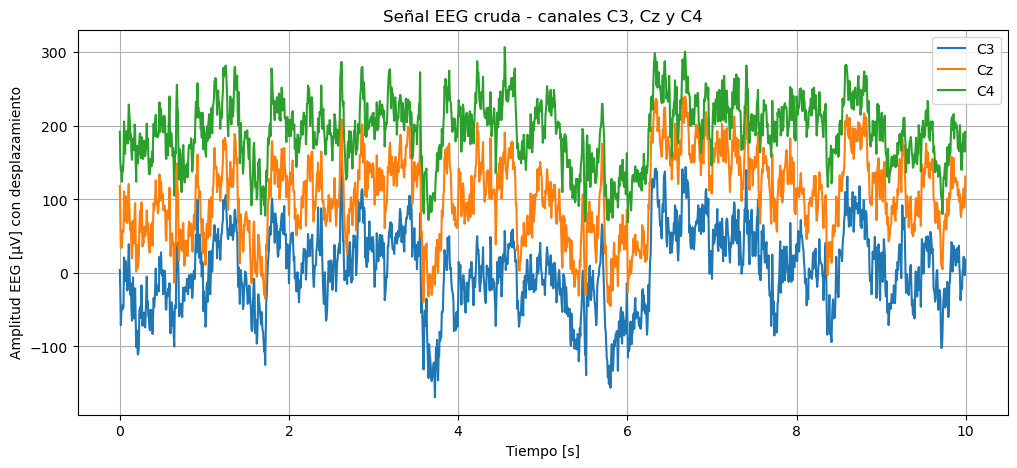

In [11]:
# ============================================================
# 11. VISUALIZAR SEÑAL CRUDA
# ============================================================

duracion_segundos = 10
sfreq = raw_canales.info["sfreq"]
n_muestras = int(duracion_segundos * sfreq)

data, times = raw_canales[:, :n_muestras]

# Pasamos de voltios a microvoltios para visualizar mejor
data_uv = data * 1e6

plt.figure(figsize=(12, 5))

offset = 100

for i, canal in enumerate(raw_canales.ch_names):
    plt.plot(times, data_uv[i] + i * offset, label=canal)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud EEG [µV] con desplazamiento")
plt.title("Señal EEG cruda - canales C3, Cz y C4")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# ============================================================
# 12. SEÑAL LISTA PARA FILTRAR
# ============================================================

raw_para_filtrar = raw_canales.copy()

print("Señal lista para aplicar filtros:")
print(raw_para_filtrar)

Señal lista para aplicar filtros:
<RawEDF | S001R04.edf, 3 x 20000 (125.0 s), ~476 KiB, data loaded>


In [13]:
# ============================================================
# 13. FILTRADO PASABANDA 8-30 Hz
# ============================================================

raw_filtrado = raw_para_filtrar.copy().filter(
    l_freq=8,
    h_freq=30,
    fir_design="firwin",
    verbose=False
)

print(raw_filtrado)

<RawEDF | S001R04.edf, 3 x 20000 (125.0 s), ~476 KiB, data loaded>


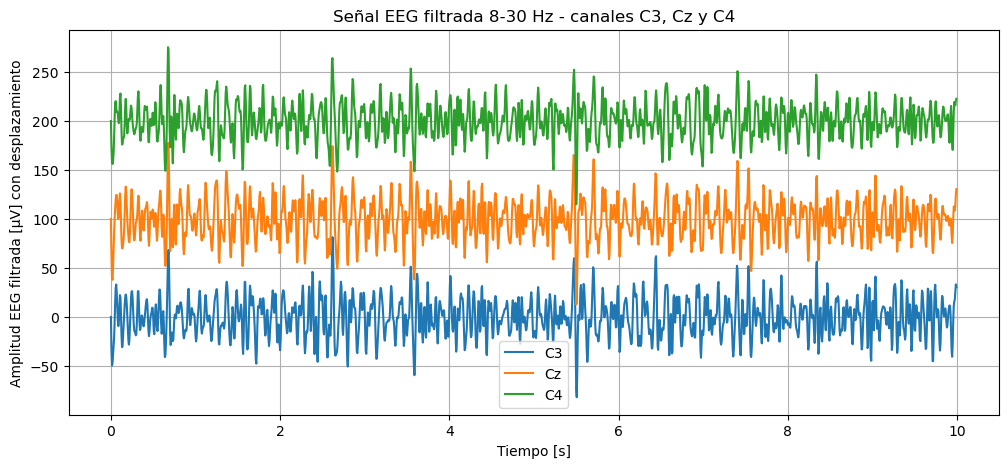

In [14]:
# Visualizar señal filtrada

data_filt, times = raw_filtrado[:, :n_muestras]
data_filt_uv = data_filt * 1e6

plt.figure(figsize=(12, 5))

for i, canal in enumerate(raw_filtrado.ch_names):
    plt.plot(times, data_filt_uv[i] + i * offset, label=canal)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud EEG filtrada [µV] con desplazamiento")
plt.title("Señal EEG filtrada 8-30 Hz - canales C3, Cz y C4")
plt.legend()
plt.grid(True)
plt.show()

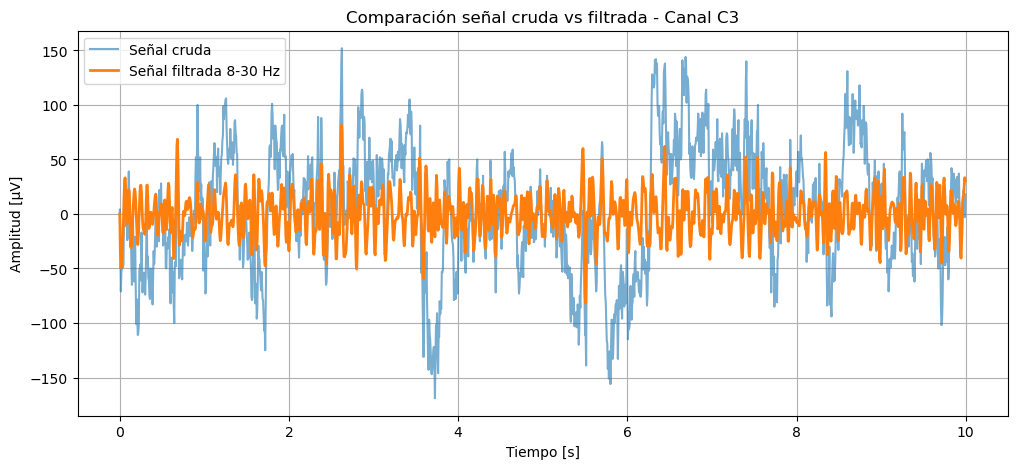

In [15]:
# Comparar señal cruda vs señal filtrada en C3

canal = "C3"
duracion_segundos = 10

sfreq = raw_canales.info["sfreq"]
n_muestras = int(duracion_segundos * sfreq)

data_cruda, times = raw_canales.copy().pick([canal])[:, :n_muestras]
data_filtrada, _ = raw_filtrado.copy().pick([canal])[:, :n_muestras]

plt.figure(figsize=(12, 5))

plt.plot(times, data_cruda[0] * 1e6, label="Señal cruda", alpha=0.6)
plt.plot(times, data_filtrada[0] * 1e6, label="Señal filtrada 8-30 Hz", linewidth=2)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [µV]")
plt.title("Comparación señal cruda vs filtrada - Canal C3")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# ============================================================
# 14. CONVERTIR ANOTACIONES EN EVENTOS
# ============================================================

events, event_id_original = mne.events_from_annotations(
    raw_filtrado,
    verbose=False
)

print("Diccionario original de eventos:")
print(event_id_original)

print("\nPrimeros eventos:")
print(events[:10])

Diccionario original de eventos:
{'T0': 1, 'T1': 2, 'T2': 3}

Primeros eventos:
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


In [17]:
# ============================================================
# 15. DEFINIR CONDICIONES DE INTERÉS
# ============================================================

event_id = {
    "reposo": event_id_original["T0"],
    "mano_izquierda_imaginada": event_id_original["T1"],
    "mano_derecha_imaginada": event_id_original["T2"]
}

print(event_id)

{'reposo': 1, 'mano_izquierda_imaginada': 2, 'mano_derecha_imaginada': 3}


In [18]:
# ============================================================
# 16. CREAR ÉPOCAS DE EEG
# ============================================================

tmin = 0      # inicio del segmento justo en el evento
tmax = 4      # duración del segmento en segundos

epochs = mne.Epochs(
    raw_filtrado,
    events,
    event_id=event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True,
    verbose=False
)

print(epochs)

<Epochs | 30 events (all good), 0 – 4 s (baseline off), ~458 KiB, data loaded,
 'reposo': 15
 'mano_izquierda_imaginada': 8
 'mano_derecha_imaginada': 7>


In [19]:
# ============================================================
# 17. CONTAR ÉPOCAS POR CONDICIÓN
# ============================================================

for condicion in event_id.keys():
    print(condicion, ":", len(epochs[condicion]))

reposo : 15
mano_izquierda_imaginada : 8
mano_derecha_imaginada : 7


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21384\2386812825.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked.plot(


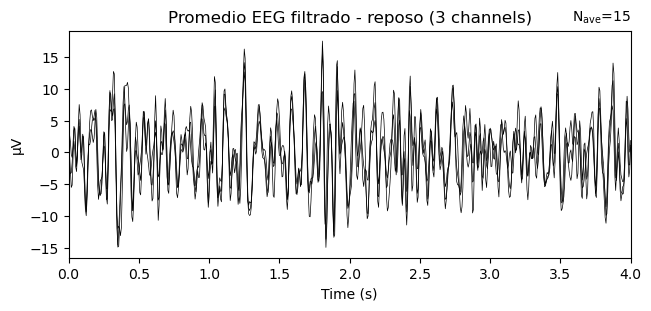

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21384\2386812825.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked.plot(


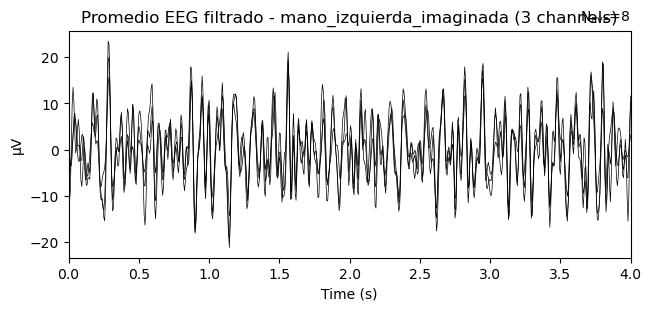

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21384\2386812825.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked.plot(


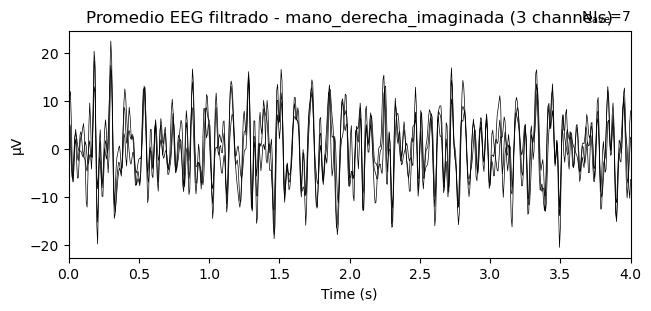

In [20]:
# ============================================================
# 18. PROMEDIO DE SEÑAL POR CONDICIÓN
# ============================================================

for condicion in event_id.keys():
    evoked = epochs[condicion].average()
    evoked.plot(
        picks=["C3", "Cz", "C4"],
        titles=f"Promedio EEG filtrado - {condicion}",
        spatial_colors=True
    )

In [23]:
# ============================================================
# 19. EXTRAER DATOS EN FORMATO NUMPY
# ============================================================

X = epochs.get_data()   # forma: épocas x canales x muestras
y = epochs.events[:, -1]

print('segmentos, canales, muestras')
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


segmentos, canales, muestras
Forma de X: (30, 3, 641)
Forma de y: (30,)


In [26]:
# ============================================================
# 20. DATAFRAME DE ÉPOCAS
# ============================================================

id_a_condicion = {v: k for k, v in event_id.items()}

df_epochs = pd.DataFrame({
    "epoca": np.arange(len(y)),
    "codigo_evento": y,
    "condicion": [id_a_condicion[codigo] for codigo in y]
})

df_epochs.head()


,epoca,codigo_evento,condicion
0,0,1,reposo
1,1,3,mano_derecha_imaginada
2,2,1,reposo
3,3,2,mano_izquierda_imaginada
4,4,1,reposo


In [27]:
df_epochs["condicion"].value_counts()

condicion
reposo                      15
mano_izquierda_imaginada     8
mano_derecha_imaginada       7
Name: count, dtype: int64

In [28]:
# ============================================================
# 21. GUARDAR ÉPOCAS PROCESADAS
# ============================================================

epochs.save(
    RESULTS_DIR / "S001R04_epocas_filtradas-epo.fif",
    overwrite=True
)

df_epochs.to_csv(
    RESULTS_DIR / "S001R04_info_epocas.csv",
    index=False
)

print("Épocas guardadas correctamente.")

Épocas guardadas correctamente.
